# Particle tracking: simulate a movie, follow the particles, recover D

Where RICS measures an *ensemble* through a fixed focus, single-particle
tracking follows each molecule individually and measures the path it actually
took. That is what lets it separate two populations with different mobilities
from one population with an intermediate mobility — something no correlation
decay can do on its own.

It is also the analysis with the most ways to be quietly wrong, because a
single mis-linked pair invents a displacement that never happened and the
resulting diffusion coefficient looks entirely reasonable.

This notebook runs the loop on data whose answer is known:

1. **simulate** a movie of Brownian particles with a chosen `D`;
2. **detect** them in every frame, and check the detections;
3. **link** them into trajectories — and see what breaks the linking;
4. **recover** `D` from the mean squared displacement, with an honest error bar.

Theory: *Concepts → Single-particle tracking*. GUI: *Guides → Particle
tracking*.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from chisurf.core.fluorescence.imaging import tracking as tk

plt.rcParams["figure.dpi"] = 110

## 1. Simulate a movie

`simulate_particle_movie` prescribes the motion, so the recovered `D` can be
checked against a known answer rather than merely looking plausible. It returns
both the movie and the **true** positions, which is what makes the linking
checkable further down.

Working in pixels and frames (`pixel_size = 1`, `frame_interval = 1`) keeps the
arithmetic transparent; set them to real values and `D` comes out in µm²/s.

movie (80, 256, 256), 640 true positions (8 particles per frame)


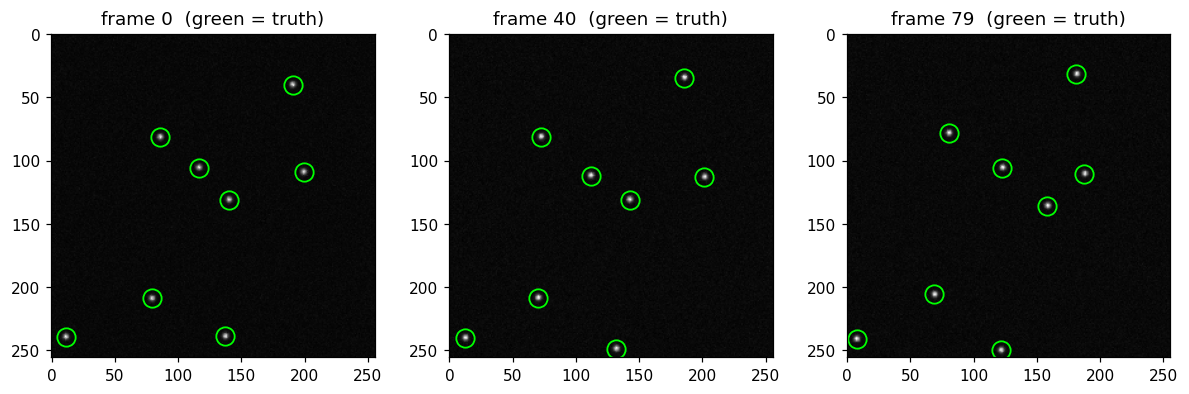

In [2]:
D_TRUE = 0.5  # pixel² per frame

movie, truth = tk.simulate_particle_movie(
    n_frames=80,
    shape=(256, 256),
    n_particles=8,
    diffusion_coefficient=D_TRUE,
    sigma_psf=1.5,      # pixels
    amplitude=250.0,    # peak counts above background
    background=10.0,
    seed=1,
)

print(f"movie {movie.shape}, {len(truth)} true positions "
      f"({len(truth) // movie.shape[0]} particles per frame)")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, f in zip(axes, (0, 40, 79)):
    ax.imshow(movie[f], cmap="gray", origin="upper")
    here = truth.in_frame(f)
    ax.plot(truth.x[here], truth.y[here], "o", mfc="none", mec="lime", ms=12, mew=1.2)
    ax.set_title(f"frame {f}  (green = truth)")
fig.tight_layout()

## 2. Detect

Detection runs on each frame independently. The default **wavelet** detector is
a multiscale product: it removes the background and rejects single hot pixels
without ever choosing an intensity threshold.

The first thing to check is always **detections per frame** against what you
expect. It is the cheapest diagnostic there is and it catches most problems.

In [3]:
detections = tk.detect_particles(movie, method="wavelet", threshold=5.0,
                                 min_separation=4.0)
print(f"{len(detections)} detections, "
      f"{len(detections) / movie.shape[0]:.1f} per frame (planted 8)")

# How accurate are the positions? Compare each detection with the nearest truth.
errors = []
for f in np.unique(detections.frame):
    found, real = detections.in_frame(f), truth.in_frame(f)
    dy = detections.y[found][:, None] - truth.y[real][None, :]
    dx = detections.x[found][:, None] - truth.x[real][None, :]
    errors.extend(np.sqrt((dy ** 2 + dx ** 2).min(axis=1)))
errors = np.array(errors)
print(f"localisation error: median {np.median(errors):.3f} px, "
      f"90th percentile {np.percentile(errors, 90):.3f} px")

640 detections, 8.0 per frame (planted 8)
localisation error: median 0.068 px, 90th percentile 0.127 px


Sub-pixel accuracy is not a nicety — it is what makes tracking possible at all.
A particle diffusing at `D` = 0.5 moves $\sqrt{4D}\approx1.4$ px per frame, so
pixel-accurate positions would bury a third of the signal in quantisation
noise.

### The threshold has to scale with the field

The number of noise pixels surviving *k* sigma is the pixel count times the
tail probability, so in principle a threshold that is clean on a small frame
floods a large one. The multiscale product suppresses almost all of it — on
this 256² field even 3σ is nearly clean, and on a 512² field the measured
counts are 9.6 / 8.0 / 8.0 per frame at 3 / 4 / 5σ against 8 planted. (A
*single* wavelet plane, without the product, gives 131 per frame at 3σ on the
same field — which is what the second scale is for.) The default of 5 has
margin at every size:

In [4]:
print(f"{'threshold':>10} {'detections/frame':>18}   (8 planted)")
for thr in (3.0, 4.0, 5.0, 8.0):
    d = tk.detect_particles(movie, threshold=thr, min_separation=4.0)
    print(f"{thr:10.1f} {len(d) / movie.shape[0]:18.1f}")

 threshold   detections/frame   (8 planted)


       3.0                8.3


       4.0                8.0


       5.0                8.0


       8.0                8.0


## 3. Link

Linking asks which detection in frame *t+1* is the same particle as which in
frame *t*. ChiSurf solves it as a **global assignment** rather than by nearest
neighbour, because when two particles approach each other both can claim the
same neighbour and the answer would otherwise depend on iteration order.

`max_distance` is the entire safety margin. Set it from the physics — about
$\sqrt{4D\Delta t}$ per frame — never from what makes the tracks look longest.

typical step  √(4D·Δt) = 1.41 px  →  max_distance ≈ 4.2 px
8 tracks, median length 80, longest 80 of 80 frames


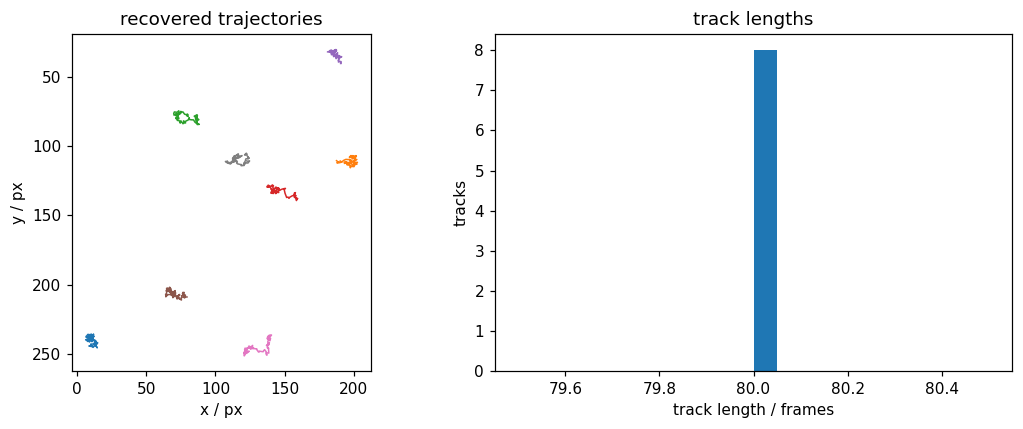

In [5]:
step = np.sqrt(4 * D_TRUE)
print(f"typical step  √(4D·Δt) = {step:.2f} px  →  max_distance ≈ {3 * step:.1f} px")

tracks = tk.link_detections(detections, max_distance=4.0, max_frame_gap=1)
lengths = tracks.lengths()
print(f"{len(tracks)} tracks, median length {int(np.median(lengths))}, "
      f"longest {lengths.max()} of {movie.shape[0]} frames")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4))
for i in tracks.ids():
    _, pos = tracks.track(i)
    ax0.plot(pos[:, 1], pos[:, 0], "-", lw=1)
ax0.set(xlabel="x / px", ylabel="y / px", title="recovered trajectories")
ax0.invert_yaxis()  # image coordinates: row 0 at the top
ax0.set_aspect("equal")

ax1.hist(lengths, bins=20)
ax1.set(xlabel="track length / frames", ylabel="tracks", title="track lengths")
fig.tight_layout()

### Did the linking keep the identities?

This is the check that matters, and it is only possible because we simulated
the data. A track that contains detections from *two different* true particles
has invented a displacement, and that displacement will inflate `D`.

In [6]:
labels = np.full(len(detections), -1)
for f in np.unique(detections.frame):
    found, real = detections.in_frame(f), truth.in_frame(f)
    dy = detections.y[found][:, None] - truth.y[real][None, :]
    dx = detections.x[found][:, None] - truth.x[real][None, :]
    sq = dy ** 2 + dx ** 2
    labels[found] = np.where(np.sqrt(sq.min(axis=1)) < 2.0, np.argmin(sq, axis=1), -1)

impure = 0
for i in tracks.ids():
    m = (tracks.track_id == i) & (labels >= 0)
    if m.sum() >= 5 and np.unique(labels[m]).size > 1:
        impure += 1
print(f"tracks mixing two different particles: {impure}  (must be 0 on a sparse field)")

tracks mixing two different particles: 0  (must be 0 on a sparse field)


### Crowding breaks tracking — the algorithm does not

When two particles come within the linking distance of one another, the
assignment is **genuinely ambiguous**: no method can resolve it from positions
alone. Packing the same field with more particles shows the failure appearing.

In [7]:
print(f"{'particles':>10} {'crowded %':>10} {'impure tracks':>14} {'D recovered':>12}")
for n_part in (8, 20, 40):
    mv, tr_truth = tk.simulate_particle_movie(
        n_frames=60, shape=(256, 256), n_particles=n_part,
        diffusion_coefficient=D_TRUE, sigma_psf=1.5, amplitude=250.0,
        background=10.0, seed=2,
    )
    det = tk.detect_particles(mv, min_separation=4.0)
    trk = tk.link_detections(det, max_distance=4.0, max_frame_gap=1)

    # How often does a true particle have a neighbour inside the linking distance?
    close = total = 0
    for f in np.unique(tr_truth.frame):
        idx = tr_truth.in_frame(f)
        p = np.column_stack([tr_truth.y[idx], tr_truth.x[idx]])
        dd = np.sqrt(((p[:, None] - p[None, :]) ** 2).sum(-1))
        np.fill_diagonal(dd, 1e9)
        close += int((dd.min(axis=1) < 4.0).sum())
        total += idx.size

    lab = np.full(len(det), -1)
    for f in np.unique(det.frame):
        fo, re = det.in_frame(f), tr_truth.in_frame(f)
        sq = ((det.y[fo][:, None] - tr_truth.y[re][None, :]) ** 2
              + (det.x[fo][:, None] - tr_truth.x[re][None, :]) ** 2)
        lab[fo] = np.where(np.sqrt(sq.min(axis=1)) < 2.0, np.argmin(sq, axis=1), -1)
    bad = sum(
        1 for i in trk.ids()
        if ((trk.track_id == i) & (lab >= 0)).sum() >= 5
        and np.unique(lab[(trk.track_id == i) & (lab >= 0)]).size > 1
    )
    try:
        d = tk.fit_msd(trk, min_length=10, fix_alpha=1.0, n_bootstrap=0)
        d_str = f"{d.diffusion_coefficient:12.3f}"
    except ValueError:
        d_str = f"{'—':>12}"
    print(f"{n_part:10d} {100 * close / total:9.1f}% {bad:14d} {d_str}")

 particles  crowded %  impure tracks  D recovered


         8       0.0%              0        0.450


        20       0.0%              0        0.442


        40       3.6%              8        0.536


Note how little crowding it takes: at 40 particles only ~4 % of them have a
neighbour inside the linking distance, and that is already enough to merge
eight tracks and shift `D`. The remedy is experimental, not computational —
label more sparsely, or image faster so the linking distance shrinks.

## 4. Recover D from the mean squared displacement

For two-dimensional diffusion,

$$\mathrm{MSD}(\tau) = 4 D \tau^{\alpha} + 4\sigma^{2}$$

Three details of that fit are not optional:

* **the offset** $\sigma$ is the localisation error; omit it and it lands in
  `D`, inflating it — badly for slow particles;
* **only short lags** are usable, because the MSD at lag *n* averages just
  *N−n* overlapping displacements;
* **`D` and α are nearly degenerate**, so fitting both roughly quadruples the
  spread of `D`. Fix α = 1 unless the question really is whether the motion is
  anomalous.

simulated D = 0.500 px²/frame
recovered D = 0.532 ± 0.094  (1.06×)
localisation error σ = 0.000 px (detector actually achieved 0.068)
from 8 tracks over 19 MSD points

  ! only 8 tracks contributed — D from this few is uncertain by tens of per cent however tight the curve looks


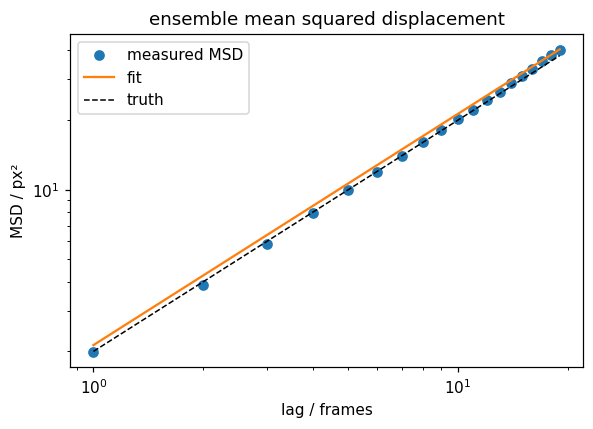

In [8]:
fit = tk.fit_msd(tracks, pixel_size=1.0, frame_interval=1.0,
                 min_length=15, fix_alpha=1.0, n_bootstrap=200)

print(f"simulated D = {D_TRUE:.3f} px²/frame")
print(f"recovered D = {fit.diffusion_coefficient:.3f} ± "
      f"{fit.diffusion_coefficient_error:.3f}  "
      f"({fit.diffusion_coefficient / D_TRUE:.2f}×)")
print(f"localisation error σ = {fit.localisation_error:.3f} px "
      f"(detector actually achieved {np.median(errors):.3f})")
# sigma comes out 0 here, and that is the right answer rather than a failure:
# the offset it would add is 4σ² ≈ 0.02 px², against an MSD of ~2 px² at lag 1.
# It is a hundred times below the signal, so the fit cannot see it — which is
# exactly the regime where leaving the term out would also have been harmless.
# For a slow particle, where the offset is a large share of the curve, it is not.
print(f"from {fit.n_tracks} tracks over {fit.n_points} MSD points\n")
for note in fit.warnings():
    print(f"  ! {note}")

fig, ax = plt.subplots(figsize=(5.5, 4))
tau = np.asarray(fit.lags, dtype=float)
ax.plot(tau, fit.msd, "o", label="measured MSD")
ax.plot(tau, 4 * fit.diffusion_coefficient * tau ** fit.alpha
        + 4 * fit.localisation_error ** 2, "-", label="fit")
ax.plot(tau, 4 * D_TRUE * tau, "k--", lw=1, label="truth")
ax.set(xlabel="lag / frames", ylabel="MSD / px²", xscale="log", yscale="log",
       title="ensemble mean squared displacement")
ax.legend()
fig.tight_layout()

### The error bar is bootstrapped, and that is not a refinement

A least-squares covariance assumes **independent residuals**. MSD points at
different lags are built from overlapping displacements of the same
trajectories, so they are strongly correlated and that assumption fails badly:
measured against simulations with a known `D`, the covariance error bar covered
the truth in 4 runs out of 20. Resampling **whole tracks** captures both the
track-to-track spread and the within-track correlation, and gives 20 out of 20.

### Fixing α is usually right

In [9]:
free = tk.fit_msd(tracks, min_length=15, n_bootstrap=200)
fixed = tk.fit_msd(tracks, min_length=15, fix_alpha=1.0, n_bootstrap=200)
print(f"α free : D = {free.diffusion_coefficient:.3f} ± "
      f"{free.diffusion_coefficient_error:.3f},  "
      f"α = {free.alpha:.2f} ± {free.alpha_error:.2f}")
print(f"α = 1  : D = {fixed.diffusion_coefficient:.3f} ± "
      f"{fixed.diffusion_coefficient_error:.3f}")
print(f"\nα = {free.alpha:.2f} ± {free.alpha_error:.2f} does not distinguish normal")
print("diffusion from mild superdiffusion — but fitting it nearly triples the")
print("uncertainty on D, and pulls the point estimate away from the truth.")

α free : D = 0.390 ± 0.266,  α = 1.10 ± 0.19
α = 1  : D = 0.532 ± 0.094

α = 1.10 ± 0.19 does not distinguish normal
diffusion from mild superdiffusion — but fitting it nearly triples the
uncertainty on D, and pulls the point estimate away from the truth.


## Summary

* Simulating the motion is what makes the answer checkable: without ground
  truth, an identity swap is invisible.
* **Detections per frame** and **the trajectory plot** catch most problems
  before any fit is run.
* Crowding, not the algorithm, sets the limit — and it bites earlier than one
  would guess. With no crowded particles at all, identity is recovered exactly;
  at only ~4 % of particles having a neighbour inside the linking distance,
  eight tracks already merged two particles and `D` moved by ~20 %.
* Fit the localisation offset, use short lags, fix α, and read the bootstrap
  error bar — the point estimate alone is not a measurement.

The companion RICS example does the same closed loop for an ensemble measured
through a scanning focus, where individual particles are never resolved.